# The World’s Mood Map: Can News Tone Predict Protests, Conflict, and Diplomacy?

**Course:** Python Data Analytics  
**Dataset:** GDELT 2.0 Event Database  
**Core idea:** Use global news event data to explore whether media tone, event type, actor countries, and attention metrics can reveal patterns of protest, conflict, and diplomacy.

## Research Questions

1. Do countries with more negative news tone experience more conflict-related events?
2. Which event types attract the most international media attention?
3. Are diplomatic events reported with a different tone than protest or conflict events?
4. How does global event intensity change across days, weeks, and hours?
5. Can we build a simple **Global Tension Index** from news tone, event severity, and media attention?

## Data Source

GDELT 2.0 master file list:  
`http://data.gdeltproject.org/gdeltv2/masterfilelist.txt`

GDELT 2.0 event files are ZIP files ending in:  
`.export.CSV.zip`

> Important: GDELT is very large. This notebook downloads a sample of recent files, enough for a strong academic project without downloading the whole database.

In [2]:
# ============================================================
# Cell 1: Install/import libraries
# ============================================================

import os
import re
import zipfile
import warnings
from io import BytesIO
from pathlib import Path
from datetime import datetime, timedelta

import requests
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 50)

print("Libraries loaded successfully.")

/Users/beltinaa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries loaded successfully.


In [3]:
# ============================================================
# Cell 2: Project configuration
# ============================================================

# GDELT updates every 15 minutes, so many files are available per day.

MASTER_FILE_URL = "http://data.gdeltproject.org/gdeltv2/masterfilelist.txt"

# Number of recent GDELT export files to download.
# 8 to 20 files is usually enough for thousands of rows.
MAX_FILES = 12

TARGET_COUNTRIES = None

# Minimum rows expected for the project.
MIN_ROWS_REQUIRED = 1000

# Folder to store downloaded files
DATA_DIR = Path("gdelt_data")
DATA_DIR.mkdir(exist_ok=True)

print("Configuration complete.")
print(f"Data folder: {DATA_DIR.resolve()}")

Configuration complete.
Data folder: /Users/beltinaa/Documents/world_mood_map_notebook/gdelt_data


## GDELT 2.0 Event Column Names

Raw GDELT `.export.CSV.zip` files do **not always include a header row**, so we define the official event schema manually.

The most important variables for this project are:

- `AvgTone`: average tone of news coverage
- `GoldsteinScale`: event cooperation/conflict score
- `QuadClass`: broad class of event
- `NumMentions`: how often the event is mentioned
- `NumSources`: number of sources covering the event
- `ActionGeo_CountryCode`: country where the event action happened
- `EventRootCode`: high-level event type
- `SQLDATE`: event date

In [4]:
# ============================================================
# Cell 3: Define GDELT 2.0 event column names
# ============================================================

GDELT_COLUMNS = [
    "GLOBALEVENTID", "SQLDATE", "MonthYear", "Year", "FractionDate",
    "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode",
    "Actor1EthnicCode", "Actor1Religion1Code", "Actor1Religion2Code",
    "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
    "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode",
    "Actor2EthnicCode", "Actor2Religion1Code", "Actor2Religion2Code",
    "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
    "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode",
    "QuadClass", "GoldsteinScale", "NumMentions", "NumSources",
    "NumArticles", "AvgTone",
    "Actor1Geo_Type", "Actor1Geo_Fullname", "Actor1Geo_CountryCode",
    "Actor1Geo_ADM1Code", "Actor1Geo_ADM2Code", "Actor1Geo_Lat",
    "Actor1Geo_Long", "Actor1Geo_FeatureID",
    "Actor2Geo_Type", "Actor2Geo_Fullname", "Actor2Geo_CountryCode",
    "Actor2Geo_ADM1Code", "Actor2Geo_ADM2Code", "Actor2Geo_Lat",
    "Actor2Geo_Long", "Actor2Geo_FeatureID",
    "ActionGeo_Type", "ActionGeo_Fullname", "ActionGeo_CountryCode",
    "ActionGeo_ADM1Code", "ActionGeo_ADM2Code", "ActionGeo_Lat",
    "ActionGeo_Long", "ActionGeo_FeatureID",
    "DATEADDED", "SOURCEURL"
]

# We only load the columns needed for the project to save memory.
USE_COLUMNS = [
    "GLOBALEVENTID", "SQLDATE", "MonthYear", "Year",
    "Actor1Name", "Actor1CountryCode",
    "Actor2Name", "Actor2CountryCode",
    "EventCode", "EventBaseCode", "EventRootCode", "QuadClass",
    "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "AvgTone",
    "ActionGeo_CountryCode", "ActionGeo_Fullname", "ActionGeo_Lat", "ActionGeo_Long",
    "DATEADDED", "SOURCEURL"
]

print(f"Total schema columns: {len(GDELT_COLUMNS)}")
print(f"Columns used in this notebook: {len(USE_COLUMNS)}")

Total schema columns: 61
Columns used in this notebook: 23


In [5]:
# ============================================================
# Cell 4: Download master file list and select recent export files
# ============================================================

def fetch_master_file_list(master_url: str) -> pd.DataFrame:
    """Download GDELT masterfilelist.txt and return only export CSV zip files."""
    response = requests.get(master_url, timeout=60)
    response.raise_for_status()

    rows = []
    for line in response.text.splitlines():
        parts = line.strip().split()
        if len(parts) >= 3:
            size, md5, url = parts[0], parts[1], parts[2]
            if url.endswith(".export.CSV.zip"):
                filename = url.split("/")[-1]
                timestamp_match = re.search(r"(\d{14})\.export\.CSV\.zip", filename)
                if timestamp_match:
                    timestamp = pd.to_datetime(timestamp_match.group(1), format="%Y%m%d%H%M%S")
                    rows.append({
                        "size_bytes": int(size),
                        "md5": md5,
                        "url": url,
                        "filename": filename,
                        "timestamp": timestamp
                    })

    df_files = pd.DataFrame(rows).sort_values("timestamp")
    return df_files

files_df = fetch_master_file_list(MASTER_FILE_URL)

print("Available GDELT export files:", len(files_df))
print("Date range:", files_df["timestamp"].min(), "to", files_df["timestamp"].max())
files_df.tail()

Available GDELT export files: 386734
Date range: 2015-02-18 23:00:00 to 2026-05-16 09:00:00


,size_bytes,md5,url,filename,timestamp
386729,53723,cb2e8b4edf77b86c02260f2aa2084226,http://data.gdeltproject.org/gdeltv2/202605160...,20260516080000.export.CSV.zip,2026-05-16 08:00:00
386730,52444,bc673dacc686bab3fccf42210d7ccc4f,http://data.gdeltproject.org/gdeltv2/202605160...,20260516081500.export.CSV.zip,2026-05-16 08:15:00
386731,59202,f5b111b90778be721c78d38e9a0d1c81,http://data.gdeltproject.org/gdeltv2/202605160...,20260516083000.export.CSV.zip,2026-05-16 08:30:00
386732,35445,1dd81c5d16280744fce99a6c8d468a57,http://data.gdeltproject.org/gdeltv2/202605160...,20260516084500.export.CSV.zip,2026-05-16 08:45:00
386733,38149,552c5801abc5a3c34d6422411a98641b,http://data.gdeltproject.org/gdeltv2/202605160...,20260516090000.export.CSV.zip,2026-05-16 09:00:00


In [6]:
# ============================================================
# Cell 5: Choose recent files to download
# ============================================================

selected_files = files_df.tail(MAX_FILES).copy()

print(f"Selected {len(selected_files)} recent export files.")
selected_files[["timestamp", "size_bytes", "url"]].head()

Selected 12 recent export files.


,timestamp,size_bytes,url
386722,2026-05-16 06:15:00,56182,http://data.gdeltproject.org/gdeltv2/202605160...
386723,2026-05-16 06:30:00,36704,http://data.gdeltproject.org/gdeltv2/202605160...
386724,2026-05-16 06:45:00,46245,http://data.gdeltproject.org/gdeltv2/202605160...
386725,2026-05-16 07:00:00,46909,http://data.gdeltproject.org/gdeltv2/202605160...
386726,2026-05-16 07:15:00,52258,http://data.gdeltproject.org/gdeltv2/202605160...


In [7]:
# ============================================================
# Cell 6: Download and read selected GDELT ZIP files
# ============================================================

def download_and_read_gdelt_file(url: str, data_dir: Path) -> pd.DataFrame:
    """Download one GDELT export ZIP file and read it into a DataFrame."""
    filename = url.split("/")[-1]
    local_zip_path = data_dir / filename

    # Download only if not already present
    if not local_zip_path.exists():
        print(f"Downloading {filename}...")
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        local_zip_path.write_bytes(response.content)
    else:
        print(f"Using cached file: {filename}")

    # Read zipped CSV
    with zipfile.ZipFile(local_zip_path, "r") as z:
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            df = pd.read_csv(
                f,
                sep="\t",
                header=None,
                names=GDELT_COLUMNS,
                usecols=USE_COLUMNS,
                dtype={
                    "GLOBALEVENTID": "Int64",
                    "SQLDATE": "Int64",
                    "Year": "Int64",
                    "QuadClass": "Int64",
                    "EventRootCode": "string",
                    "EventCode": "string",
                    "EventBaseCode": "string",
                    "Actor1CountryCode": "string",
                    "Actor2CountryCode": "string",
                    "ActionGeo_CountryCode": "string",
                    "Actor1Name": "string",
                    "Actor2Name": "string",
                    "ActionGeo_Fullname": "string",
                    "SOURCEURL": "string"
                },
                encoding="latin1",
                low_memory=False
            )
    return df

frames = []

for_url_count = 0
for url in selected_files["url"]:
    try:
        frames.append(download_and_read_gdelt_file(url, DATA_DIR))
        for_url_count += 1
    except Exception as e:
        print(f"Failed to process {url}: {e}")

raw_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print(f"Files successfully loaded: {for_url_count}")
print(f"Raw rows loaded: {len(raw_df):,}")
raw_df.head()

Files successfully loaded: 12
Raw rows loaded: 8,960


,GLOBALEVENTID,SQLDATE,MonthYear,Year,Actor1Name,Actor1CountryCode,Actor2Name,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_Fullname,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,DATEADDED,SOURCEURL
0,1304381797,20250516,202505,2025,AUSTRALIA,AUS,<NA>,<NA>,161,161,16,4,-4.0,4,1,4,-2.657343,"Bondi Beach, New South Wales, Australia",AS,-33.8902,151.2760,20260516061500,https://www.brisbanetimes.com.au/national/quee...
1,1304381798,20250516,202505,2025,ADMINISTRATION,<NA>,VENEZUELAN,VEN,138,138,13,3,-7.0,3,1,3,-3.933910,"Ohio, United States",US,40.3736,-82.7755,20260516061500,https://www.mariettatimes.com/opinion/local-co...
2,1304381799,20250516,202505,2025,PALESTINIAN,PSE,PRESIDENT,<NA>,173,173,17,4,-5.0,2,1,2,-6.578947,"Gaza, Israel (general), Israel",IS,31.4167,34.3333,20260516061500,https://www.pakistantoday.com.pk/2026/05/16/pr...
3,1304381800,20250516,202505,2025,PALESTINIAN,PSE,PRESIDENT,<NA>,174,174,17,4,-5.0,2,1,2,-6.578947,"Gaza, Israel (general), Israel",IS,31.4167,34.3333,20260516061500,https://www.pakistantoday.com.pk/2026/05/16/pr...
4,1304381801,20250516,202505,2025,PALESTINIAN,PSE,PAKISTAN,PAK,173,173,17,4,-5.0,2,1,2,-6.578947,Pakistan,PK,30.0000,70.0000,20260516061500,https://www.pakistantoday.com.pk/2026/05/16/pr...


In [8]:
# ============================================================
# Cell 7: Basic cleaning and feature engineering
# ============================================================

df = raw_df.copy()

# Convert dates
df["event_date"] = pd.to_datetime(df["SQLDATE"].astype(str), format="%Y%m%d", errors="coerce")
df["dateadded"] = pd.to_datetime(df["DATEADDED"].astype(str), format="%Y%m%d%H%M%S", errors="coerce")

# Numeric conversion
numeric_cols = [
    "GoldsteinScale", "NumMentions", "NumSources", "NumArticles",
    "AvgTone", "ActionGeo_Lat", "ActionGeo_Long"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing essential analysis variables
essential_cols = ["event_date", "QuadClass", "GoldsteinScale", "NumMentions", "NumSources", "AvgTone"]
df = df.dropna(subset=essential_cols)

# Optional country filtering
if TARGET_COUNTRIES is not None:
    df = df[df["ActionGeo_CountryCode"].isin(TARGET_COUNTRIES)]

# Add readable QuadClass labels
quad_labels = {
    1: "Verbal Cooperation",
    2: "Material Cooperation",
    3: "Verbal Conflict",
    4: "Material Conflict"
}

df["quad_label"] = df["QuadClass"].map(quad_labels)

# Simplified event category
def classify_event(row):
    root = str(row["EventRootCode"]).zfill(2)
    quad = row["QuadClass"]

    if quad in [3, 4]:
        if root in ["14"]:
            return "Protest"
        elif root in ["18", "19", "20"]:
            return "Conflict / Violence"
        elif root in ["17"]:
            return "Coercion"
        else:
            return "Other Conflict"
    elif quad in [1, 2]:
        if root in ["03", "04"]:
            return "Diplomacy / Consultation"
        elif root in ["05"]:
            return "Engagement / Cooperation"
        elif root in ["06", "07"]:
            return "Material Cooperation"
        else:
            return "Other Cooperation"
    else:
        return "Other"

df["event_category"] = df.apply(classify_event, axis=1)

# Attention score: combines mentions, sources, and articles.
# log1p prevents very large media spikes from dominating everything.
df["attention_score"] = (
    np.log1p(df["NumMentions"]) +
    np.log1p(df["NumSources"]) +
    np.log1p(df["NumArticles"])
)

# Negative tone strength
df["negative_tone"] = np.where(df["AvgTone"] < 0, abs(df["AvgTone"]), 0)

# Conflict flag
df["is_conflict"] = df["QuadClass"].isin([3, 4]).astype(int)
df["is_material_conflict"] = (df["QuadClass"] == 4).astype(int)
df["is_diplomacy"] = df["event_category"].isin(["Diplomacy / Consultation", "Engagement / Cooperation"]).astype(int)
df["is_protest"] = (df["event_category"] == "Protest").astype(int)

# Time features
df["hour_added"] = df["dateadded"].dt.hour
df["weekday"] = df["event_date"].dt.day_name()
df["week"] = df["event_date"].dt.to_period("W").astype(str)

print(f"Cleaned rows: {len(df):,}")

if len(df) < MIN_ROWS_REQUIRED:
    print("WARNING: The dataset has fewer rows than required. Increase MAX_FILES and rerun the download cells.")

df.head()

Cleaned rows: 8,960


,GLOBALEVENTID,SQLDATE,MonthYear,Year,Actor1Name,Actor1CountryCode,Actor2Name,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_Fullname,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,DATEADDED,SOURCEURL,event_date,dateadded,quad_label,event_category,attention_score,negative_tone,is_conflict,is_material_conflict,is_diplomacy,is_protest,hour_added,weekday,week
0,1304381797,20250516,202505,2025,AUSTRALIA,AUS,<NA>,<NA>,161,161,16,4,-4.0,4,1,4,-2.657343,"Bondi Beach, New South Wales, Australia",AS,-33.8902,151.2760,20260516061500,https://www.brisbanetimes.com.au/national/quee...,2025-05-16,2026-05-16 06:15:00,Material Conflict,Other Conflict,3.912023,2.657343,1,1,0,0,6,Friday,2025-05-12/2025-05-18
1,1304381798,20250516,202505,2025,ADMINISTRATION,<NA>,VENEZUELAN,VEN,138,138,13,3,-7.0,3,1,3,-3.933910,"Ohio, United States",US,40.3736,-82.7755,20260516061500,https://www.mariettatimes.com/opinion/local-co...,2025-05-16,2026-05-16 06:15:00,Verbal Conflict,Other Conflict,3.465736,3.933910,1,0,0,0,6,Friday,2025-05-12/2025-05-18
2,1304381799,20250516,202505,2025,PALESTINIAN,PSE,PRESIDENT,<NA>,173,173,17,4,-5.0,2,1,2,-6.578947,"Gaza, Israel (general), Israel",IS,31.4167,34.3333,20260516061500,https://www.pakistantoday.com.pk/2026/05/16/pr...,2025-05-16,2026-05-16 06:15:00,Material Conflict,Coercion,2.890372,6.578947,1,1,0,0,6,Friday,2025-05-12/2025-05-18
3,1304381800,20250516,202505,2025,PALESTINIAN,PSE,PRESIDENT,<NA>,174,174,17,4,-5.0,2,1,2,-6.578947,"Gaza, Israel (general), Israel",IS,31.4167,34.3333,20260516061500,https://www.pakistantoday.com.pk/2026/05/16/pr...,2025-05-16,2026-05-16 06:15:00,Material Conflict,Coercion,2.890372,6.578947,1,1,0,0,6,Friday,2025-05-12/2025-05-18
4,1304381801,20250516,202505,2025,PALESTINIAN,PSE,PAKISTAN,PAK,173,173,17,4,-5.0,2,1,2,-6.578947,Pakistan,PK,30.0000,70.0000,20260516061500,https://www.pakistantoday.com.pk/2026/05/16/pr...,2025-05-16,2026-05-16 06:15:00,Material Conflict,Coercion,2.890372,6.578947,1,1,0,0,6,Friday,2025-05-12/2025-05-18


In [9]:
# ============================================================
# Cell 8: Dataset quality check
# ============================================================

print("Shape:", df.shape)
print("\nMissing values in selected columns:")
print(df[USE_COLUMNS].isna().mean().sort_values(ascending=False).head(15))

print("\nEvent date range:")
print(df["event_date"].min(), "to", df["event_date"].max())

print("\nUnique countries:", df["ActionGeo_CountryCode"].nunique())
print("\nQuadClass distribution:")
print(df["quad_label"].value_counts(dropna=False))

Shape: (8960, 36)

Missing values in selected columns:
Actor2CountryCode        0.547879
Actor1CountryCode        0.430469
Actor2Name               0.283482
Actor1Name               0.094531
ActionGeo_Long           0.028795
ActionGeo_Lat            0.028795
ActionGeo_Fullname       0.028795
ActionGeo_CountryCode    0.028795
GLOBALEVENTID            0.000000
NumSources               0.000000
DATEADDED                0.000000
AvgTone                  0.000000
NumArticles              0.000000
QuadClass                0.000000
NumMentions              0.000000
dtype: float64

Event date range:
2025-05-16 00:00:00 to 2026-05-16 00:00:00

Unique countries: 138

QuadClass distribution:
quad_label
Verbal Cooperation      5614
Material Conflict       1255
Verbal Conflict         1138
Material Cooperation     953
Name: count, dtype: int64


In [10]:
# ============================================================
# Cell 9: Descriptive statistics
# ============================================================

summary_cols = ["AvgTone", "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "attention_score"]
df[summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
AvgTone,8960.0,-1.769484,4.135464,-19.919517,-4.452249,-1.857603,0.766284,14.634146
GoldsteinScale,8960.0,0.568259,4.742634,-10.000000,-2.000000,1.900000,3.400000,10.000000
NumMentions,8960.0,4.701562,4.909085,1.000000,2.000000,4.000000,6.000000,178.000000
NumSources,8960.0,1.044754,0.620289,1.000000,1.000000,1.000000,1.000000,15.000000
NumArticles,8960.0,4.597433,4.579334,1.000000,2.000000,4.000000,6.000000,150.000000
attention_score,8960.0,3.784031,1.223165,2.079442,2.890372,3.912023,4.584967,12.977254


# Analysis Question 1

## Do countries with more negative news tone experience more conflict-related events?

We aggregate by country and compare:

- average tone
- conflict event share
- material conflict share
- total number of events
- average Goldstein Scale
- average media attention

In [11]:
# ============================================================
# Cell 10: Country-level mood/conflict table
# ============================================================

country_stats = (
    df.dropna(subset=["ActionGeo_CountryCode"])
      .groupby("ActionGeo_CountryCode")
      .agg(
          events=("GLOBALEVENTID", "count"),
          avg_tone=("AvgTone", "mean"),
          median_tone=("AvgTone", "median"),
          conflict_share=("is_conflict", "mean"),
          material_conflict_share=("is_material_conflict", "mean"),
          protest_share=("is_protest", "mean"),
          diplomacy_share=("is_diplomacy", "mean"),
          avg_goldstein=("GoldsteinScale", "mean"),
          avg_attention=("attention_score", "mean"),
          total_mentions=("NumMentions", "sum")
      )
      .reset_index()
)

# Keep countries with enough observations for reliable comparison
country_stats = country_stats[country_stats["events"] >= 20].copy()

country_stats.sort_values("conflict_share", ascending=False).head(10)

,ActionGeo_CountryCode,events,avg_tone,median_tone,conflict_share,material_conflict_share,protest_share,diplomacy_share,avg_goldstein,avg_attention,total_mentions
1,AF,28,-7.412332,-7.975460,0.678571,0.500000,0.035714,0.071429,-3.592857,4.098245,160
31,CU,73,-4.682440,-4.770531,0.493151,0.273973,0.013699,0.191781,-1.846575,3.521782,281
65,IZ,25,-3.107641,-3.789127,0.480000,0.320000,0.000000,0.240000,-0.920000,3.716981,111
118,TH,21,-0.093929,1.666667,0.476190,0.333333,0.000000,0.238095,-1.804762,3.994624,104
84,MX,39,-0.673624,0.000000,0.461538,0.230769,0.000000,0.461538,-0.202564,3.256222,121
63,IS,258,-4.444317,-4.452830,0.445736,0.240310,0.019380,0.290698,-1.205426,3.373433,901
132,WE,27,-1.232452,-4.800000,0.444444,0.259259,0.000000,0.407407,-0.385185,2.637444,50
4,AM,36,-1.220087,-1.573427,0.444444,0.138889,0.000000,0.361111,-1.097222,3.382032,131
97,PK,204,-4.599938,-5.467217,0.382353,0.220588,0.000000,0.328431,-1.174020,3.715218,873
87,NI,700,-1.404851,-1.161103,0.358571,0.211429,0.004286,0.314286,-0.562571,3.640206,3392


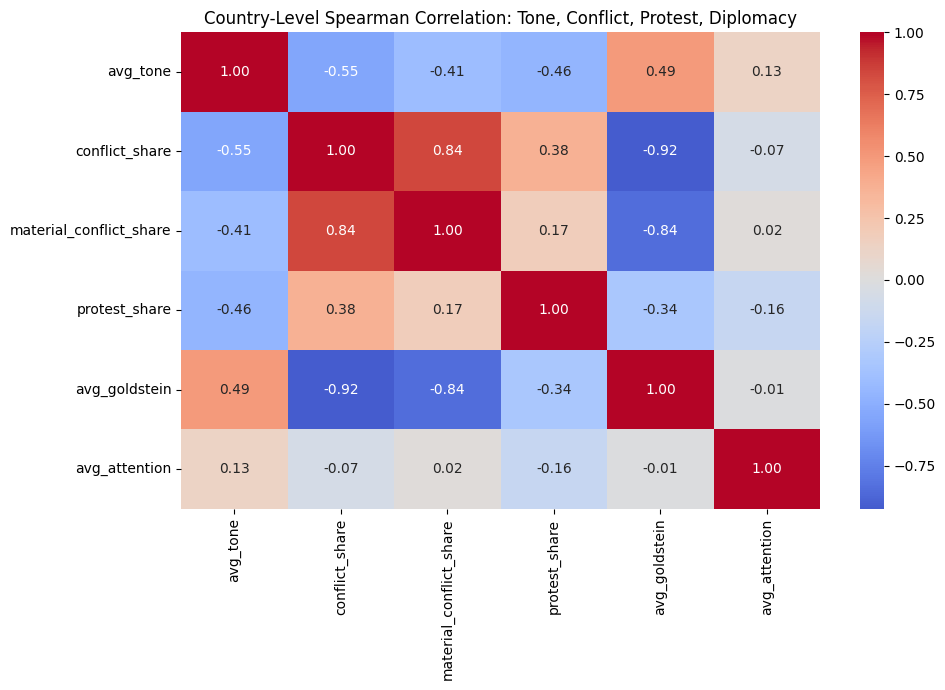

In [12]:
# ============================================================
# Cell 11: Correlation between tone and conflict indicators
# ============================================================

corr_cols = ["avg_tone", "conflict_share", "material_conflict_share", "protest_share", "avg_goldstein", "avg_attention"]
country_corr = country_stats[corr_cols].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(country_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Country-Level Spearman Correlation: Tone, Conflict, Protest, Diplomacy")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Cell 12: Scatter plot — average tone vs conflict share
# ============================================================
import plotly.io as pio

pio.renderers.default = "browser"

fig = px.scatter(
    country_stats,
    x="avg_tone",
    y="conflict_share",
    size="events",
    hover_name="ActionGeo_CountryCode",
    hover_data=["events", "avg_goldstein", "avg_attention", "protest_share"],
    title="Do Countries with More Negative News Tone Have More Conflict Events?",
    labels={
        "avg_tone": "Average News Tone",
        "conflict_share": "Share of Conflict Events",
        "events": "Number of Events"
    }
)

fig.show()

In [17]:
# ============================================================
# Cell 13: Choropleth map — average tone by country
# ============================================================

fig = px.choropleth(
    country_stats,
    locations="ActionGeo_CountryCode",
    color="avg_tone",
    hover_name="ActionGeo_CountryCode",
    hover_data=["events", "conflict_share", "avg_goldstein"],
    title="World Mood Map: Average News Tone by Country",
    color_continuous_scale="RdBu"
)

fig.show()

# Analysis Question 2

## Which event types attract the most international media attention?

We rank event categories using:

- total events
- total mentions
- average number of sources
- average attention score
- average tone
- average Goldstein Scale

In [18]:
# ============================================================
# Cell 14: Event-category attention table
# ============================================================

category_stats = (
    df.groupby("event_category")
      .agg(
          events=("GLOBALEVENTID", "count"),
          avg_tone=("AvgTone", "mean"),
          avg_goldstein=("GoldsteinScale", "mean"),
          avg_mentions=("NumMentions", "mean"),
          total_mentions=("NumMentions", "sum"),
          avg_sources=("NumSources", "mean"),
          avg_articles=("NumArticles", "mean"),
          avg_attention=("attention_score", "mean"),
          conflict_share=("is_conflict", "mean")
      )
      .reset_index()
      .sort_values("avg_attention", ascending=False)
)

category_stats

,event_category,events,avg_tone,avg_goldstein,avg_mentions,total_mentions,avg_sources,avg_articles,avg_attention,conflict_share
6,Other Cooperation,2323,-2.185503,1.423461,4.942316,11481,1.061989,4.816616,3.876216,0.0
4,Material Cooperation,447,-1.562029,6.782327,4.762864,2129,1.008949,4.751678,3.863838,0.0
1,Conflict / Violence,772,-4.853567,-9.807642,5.205959,4019,1.186528,5.053109,3.791183,1.0
5,Other Conflict,1212,-3.174696,-3.524587,4.539604,5502,1.016502,4.478548,3.774732,1.0
2,Diplomacy / Consultation,2984,-0.265554,3.179658,4.553284,13587,1.020107,4.440349,3.731593,0.0
3,Engagement / Cooperation,813,0.523393,4.159779,4.400984,3578,1.019680,4.321033,3.725568,0.0
0,Coercion,368,-5.210512,-5.451087,4.532609,1668,1.035326,4.418478,3.695816,1.0
7,Protest,41,-4.887153,-6.524390,3.951220,162,1.000000,3.951220,3.598610,1.0


In [19]:
# ============================================================
# Cell 15: Bubble chart — media attention by event category
# ============================================================

fig = px.scatter(
    category_stats,
    x="avg_goldstein",
    y="avg_tone",
    size="total_mentions",
    color="event_category",
    hover_name="event_category",
    hover_data=["events", "avg_attention", "conflict_share"],
    title="Which Event Categories Attract the Most Media Attention?",
    labels={
        "avg_goldstein": "Average Goldstein Scale",
        "avg_tone": "Average News Tone",
        "total_mentions": "Total Mentions"
    }
)

fig.show()

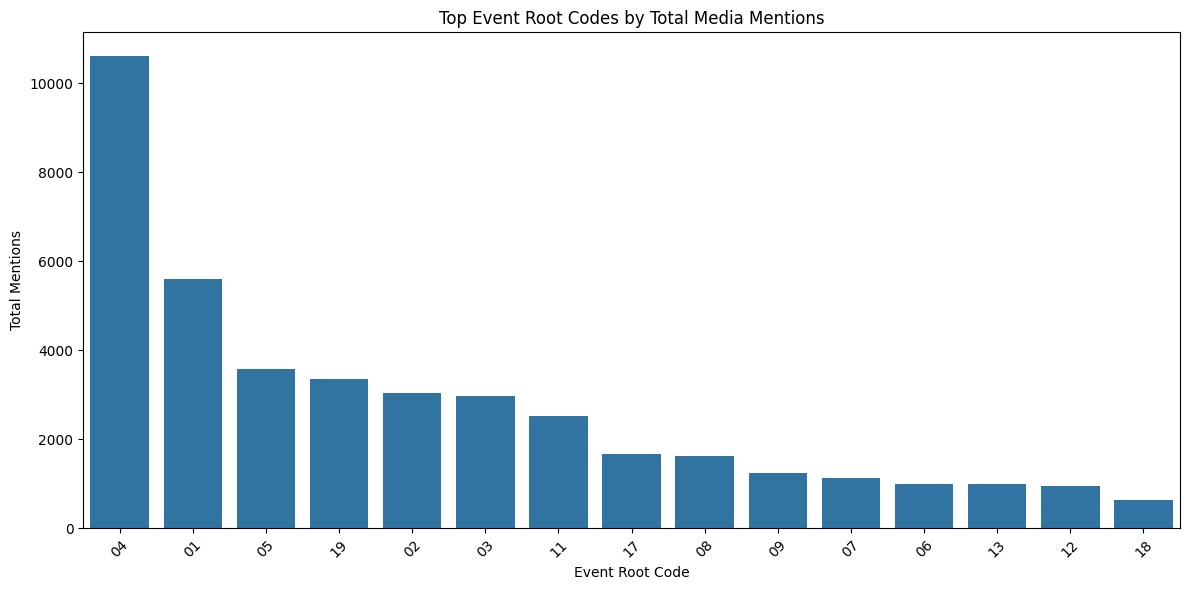

,EventRootCode,events,total_mentions,avg_tone,avg_goldstein
3,04,2353,10609,-0.397156,2.922609
0,01,1258,5590,-2.143221,0.014865
4,05,813,3578,0.523393,4.159779
18,19,627,3346,-4.560845,-9.960925
1,02,559,3030,-1.613275,2.976744
2,03,631,2978,0.225191,4.138193
10,11,568,2528,-3.198591,-2.000000
16,17,368,1668,-5.210512,-5.451087
7,08,309,1622,-2.586792,6.530744
8,09,197,1239,-3.449806,-2.000000


In [20]:
# ============================================================
# Cell 16: Bar chart — top event root codes by total mentions
# ============================================================

root_stats = (
    df.groupby("EventRootCode")
      .agg(
          events=("GLOBALEVENTID", "count"),
          total_mentions=("NumMentions", "sum"),
          avg_tone=("AvgTone", "mean"),
          avg_goldstein=("GoldsteinScale", "mean")
      )
      .reset_index()
      .sort_values("total_mentions", ascending=False)
      .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=root_stats, x="EventRootCode", y="total_mentions")
plt.title("Top Event Root Codes by Total Media Mentions")
plt.xlabel("Event Root Code")
plt.ylabel("Total Mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

root_stats

# Analysis Question 3

## Are diplomatic events reported with a different tone than protest or conflict events?

Here we compare distributions of `AvgTone` and `GoldsteinScale` across event categories.

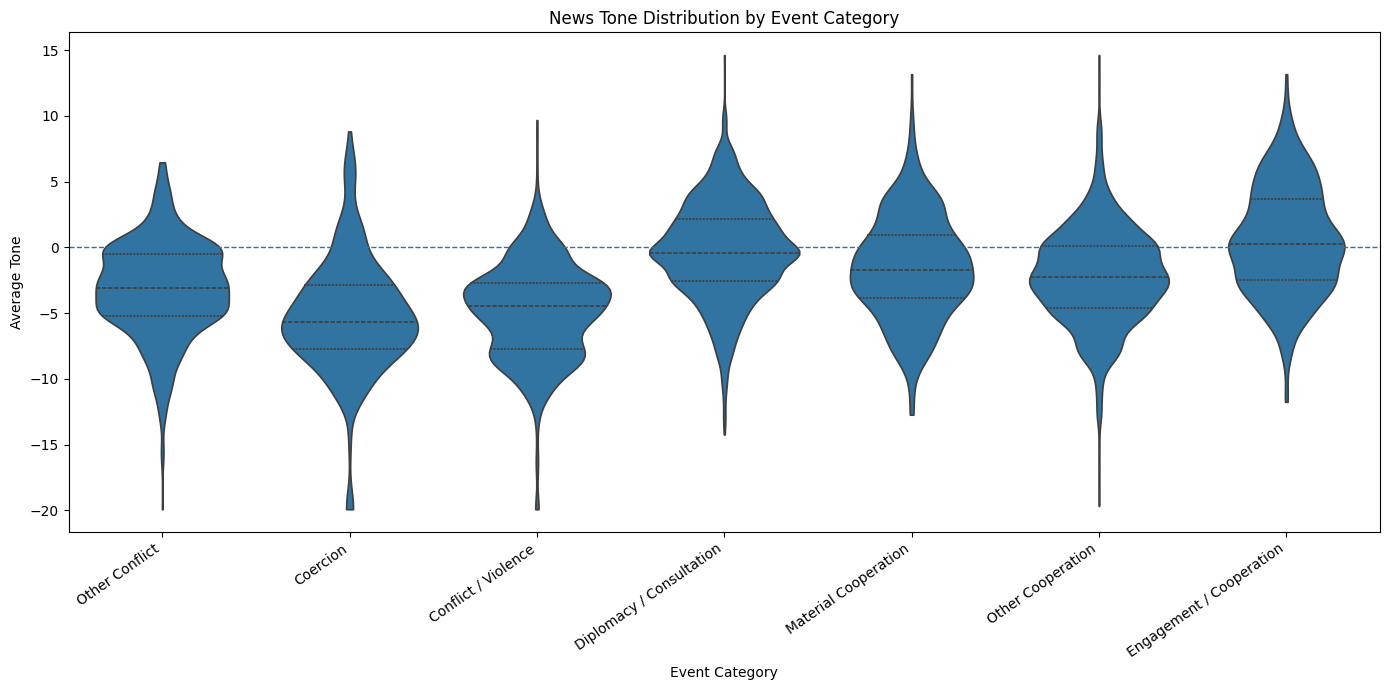

In [21]:
# ============================================================
# Cell 17: Distribution of news tone by event category
# ============================================================

major_categories = category_stats[category_stats["events"] >= 50]["event_category"].tolist()
df_major = df[df["event_category"].isin(major_categories)].copy()

plt.figure(figsize=(14, 7))
sns.violinplot(
    data=df_major,
    x="event_category",
    y="AvgTone",
    inner="quartile",
    cut=0
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("News Tone Distribution by Event Category")
plt.xlabel("Event Category")
plt.ylabel("Average Tone")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Cell 18: Boxplot of Goldstein Scale by event category
# ============================================================

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_major,
    x="event_category",
    y="GoldsteinScale"
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Goldstein Scale by Event Category")
plt.xlabel("Event Category")
plt.ylabel("Goldstein Scale")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Cell 19: Summary comparison: diplomacy vs protest vs conflict
# ============================================================

comparison_groups = df[df["event_category"].isin([
    "Diplomacy / Consultation",
    "Engagement / Cooperation",
    "Protest",
    "Conflict / Violence",
    "Coercion"
])].copy()

comparison_summary = (
    comparison_groups.groupby("event_category")
    .agg(
        events=("GLOBALEVENTID", "count"),
        avg_tone=("AvgTone", "mean"),
        median_tone=("AvgTone", "median"),
        avg_goldstein=("GoldsteinScale", "mean"),
        avg_mentions=("NumMentions", "mean"),
        avg_sources=("NumSources", "mean")
    )
    .reset_index()
    .sort_values("avg_goldstein")
)

comparison_summary

,event_category,events,avg_tone,median_tone,avg_goldstein,avg_mentions,avg_sources
1,Conflict / Violence,772,-4.853567,-4.452830,-9.807642,5.205959,1.186528
4,Protest,41,-4.887153,-4.251386,-6.524390,3.951220,1.000000
0,Coercion,368,-5.210512,-5.687204,-5.451087,4.532609,1.035326
2,Diplomacy / Consultation,2984,-0.265554,-0.464037,3.179658,4.553284,1.020107
3,Engagement / Cooperation,813,0.523393,0.223214,4.159779,4.400984,1.019680


# Analysis Question 4

## How does global event intensity change across time?

We study:

- daily volume of events
- daily average tone
- daily conflict share
- hourly activity patterns

In [23]:
# ============================================================
# Cell 20: Daily time-series table
# ============================================================

daily = (
    df.groupby("event_date")
      .agg(
          events=("GLOBALEVENTID", "count"),
          avg_tone=("AvgTone", "mean"),
          conflict_share=("is_conflict", "mean"),
          protest_events=("is_protest", "sum"),
          diplomacy_events=("is_diplomacy", "sum"),
          total_mentions=("NumMentions", "sum"),
          avg_attention=("attention_score", "mean")
      )
      .reset_index()
      .sort_values("event_date")
)

daily["rolling_avg_tone"] = daily["avg_tone"].rolling(3, min_periods=1).mean()
daily["rolling_conflict_share"] = daily["conflict_share"].rolling(3, min_periods=1).mean()

daily.head()

,event_date,events,avg_tone,conflict_share,protest_events,diplomacy_events,total_mentions,avg_attention,rolling_avg_tone,rolling_conflict_share
0,2025-05-16,77,-3.573533,0.519481,0,12,273,3.428435,-3.573533,0.519481
1,2026-04-16,46,-1.036776,0.130435,0,24,196,3.709912,-2.305154,0.324958
2,2026-05-09,38,-2.553989,0.210526,0,13,117,3.082440,-2.388099,0.286814
3,2026-05-15,43,-1.868704,0.186047,0,31,88,2.718124,-1.819823,0.175669
4,2026-05-16,8756,-1.753576,0.266217,41,3717,41452,3.795827,-2.058757,0.220930


In [24]:
# ============================================================
# Cell 21: Line chart — events and tone over time
# ============================================================

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily["event_date"],
    y=daily["events"],
    mode="lines+markers",
    name="Event Volume",
    yaxis="y1"
))

fig.add_trace(go.Scatter(
    x=daily["event_date"],
    y=daily["rolling_avg_tone"],
    mode="lines+markers",
    name="Rolling Avg Tone",
    yaxis="y2"
))

fig.update_layout(
    title="Global Event Volume and News Tone Over Time",
    xaxis=dict(title="Date"),
    yaxis=dict(title="Number of Events"),
    yaxis2=dict(title="Average Tone", overlaying="y", side="right"),
    legend=dict(x=0.01, y=0.99)
)

fig.show()

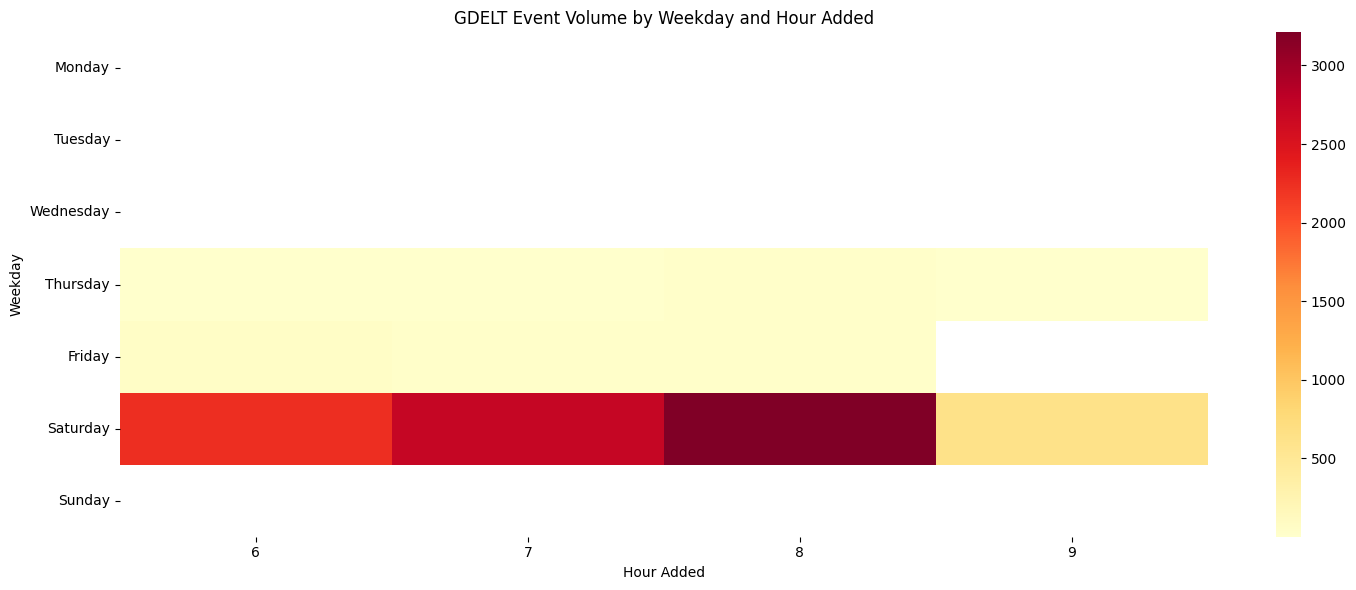

In [25]:
# ============================================================
# Cell 22: Heatmap — events by weekday and hour
# ============================================================

hour_weekday = (
    df.dropna(subset=["hour_added", "weekday"])
      .groupby(["weekday", "hour_added"])
      .size()
      .reset_index(name="events")
)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

hour_pivot = hour_weekday.pivot(index="weekday", columns="hour_added", values="events")
hour_pivot = hour_pivot.reindex(weekday_order)

plt.figure(figsize=(15, 6))
sns.heatmap(hour_pivot, cmap="YlOrRd")
plt.title("GDELT Event Volume by Weekday and Hour Added")
plt.xlabel("Hour Added")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# Cell 23: Stacked area chart — event category over time
# ============================================================

category_time = (
    df.groupby(["event_date", "event_category"])
      .size()
      .reset_index(name="events")
)

category_pivot = category_time.pivot(
    index="event_date",
    columns="event_category",
    values="events"
).fillna(0)

fig = px.area(
    category_pivot.reset_index(),
    x="event_date",
    y=category_pivot.columns,
    title="Event Categories Over Time",
    labels={"value": "Number of Events", "event_date": "Date"}
)

fig.show()

# Bonus Analysis

## Global Tension Index

We create a simple index using:

- negative tone
- conflict share
- material conflict share
- media attention
- inverse Goldstein score

This is not an official index. It is a student-created analytical metric for storytelling and ranking.

In [27]:
# ============================================================
# Cell 24: Build country-level Global Tension Index
# ============================================================

tension = country_stats.copy()

# Components
tension["negative_tone_score"] = np.maximum(-tension["avg_tone"], 0)
tension["inverse_goldstein"] = np.maximum(-tension["avg_goldstein"], 0)

index_features = [
    "negative_tone_score",
    "conflict_share",
    "material_conflict_share",
    "avg_attention",
    "inverse_goldstein"
]

# Standardize features before combining
scaler = StandardScaler()
scaled = scaler.fit_transform(tension[index_features].fillna(0))

tension["global_tension_index"] = scaled.mean(axis=1)

# Rescale to 0-100 for presentation
min_val = tension["global_tension_index"].min()
max_val = tension["global_tension_index"].max()
tension["global_tension_index_0_100"] = (
    100 * (tension["global_tension_index"] - min_val) / (max_val - min_val)
)

tension_ranked = tension.sort_values("global_tension_index_0_100", ascending=False)

tension_ranked.head(15)

,ActionGeo_CountryCode,events,avg_tone,median_tone,conflict_share,material_conflict_share,protest_share,diplomacy_share,avg_goldstein,avg_attention,total_mentions,negative_tone_score,inverse_goldstein,global_tension_index,global_tension_index_0_100
1,AF,28,-7.412332,-7.975460,0.678571,0.500000,0.035714,0.071429,-3.592857,4.098245,160,7.412332,3.592857,3.306581,100.000000
31,CU,73,-4.682440,-4.770531,0.493151,0.273973,0.013699,0.191781,-1.846575,3.521782,281,4.682440,1.846575,1.411462,56.659869
118,TH,21,-0.093929,1.666667,0.476190,0.333333,0.000000,0.238095,-1.804762,3.994624,104,0.093929,1.804762,1.208861,52.026509
65,IZ,25,-3.107641,-3.789127,0.480000,0.320000,0.000000,0.240000,-0.920000,3.716981,111,3.107641,0.920000,1.107762,49.714459
97,PK,204,-4.599938,-5.467217,0.382353,0.220588,0.000000,0.328431,-1.174020,3.715218,873,4.599938,1.174020,1.030804,47.954480
63,IS,258,-4.444317,-4.452830,0.445736,0.240310,0.019380,0.290698,-1.205426,3.373433,901,4.444317,1.205426,0.965910,46.470398
104,RP,45,-4.464274,-5.988024,0.355556,0.155556,0.000000,0.177778,-0.364444,4.076109,227,4.464274,0.364444,0.781793,42.259753
115,SY,39,-0.504676,-0.347222,0.333333,0.256410,0.000000,0.384615,-0.638462,4.164967,203,0.504676,0.638462,0.624091,38.653221
6,AS,281,-3.349158,-2.795031,0.259786,0.085409,0.010676,0.444840,0.888968,4.310537,1848,3.349158,0.000000,0.388239,33.259428
20,CA,109,-1.206770,-0.545331,0.357798,0.183486,0.000000,0.302752,-0.504587,3.855518,535,1.206770,0.504587,0.385678,33.200860


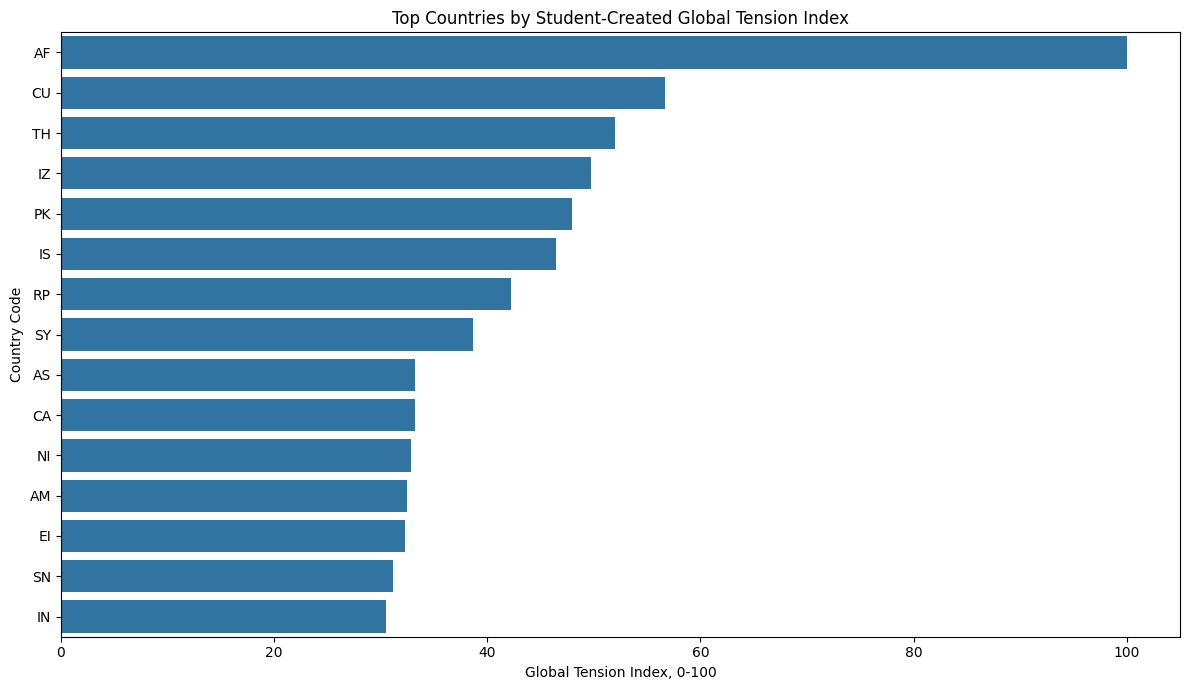

In [28]:
# ============================================================
# Cell 25: Bar chart — top countries by Global Tension Index
# ============================================================

top_tension = tension_ranked.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_tension,
    x="global_tension_index_0_100",
    y="ActionGeo_CountryCode"
)
plt.title("Top Countries by Student-Created Global Tension Index")
plt.xlabel("Global Tension Index, 0-100")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# Cell 26: Choropleth — Global Tension Index
# ============================================================

fig = px.choropleth(
    tension,
    locations="ActionGeo_CountryCode",
    color="global_tension_index_0_100",
    hover_name="ActionGeo_CountryCode",
    hover_data=["events", "avg_tone", "conflict_share", "avg_goldstein", "avg_attention"],
    title="Student-Created Global Tension Index by Country",
    color_continuous_scale="Reds"
)

fig.show()

# Optional Machine Learning Extension

## Country Clustering

We cluster countries based on:

- average tone
- conflict share
- protest share
- diplomacy share
- average Goldstein Scale
- media attention

This can identify groups such as:

- high-conflict / high-attention countries
- low-conflict / diplomatic countries
- negative-tone but low-event countries

In [30]:
# ============================================================
# Cell 27: KMeans clustering of country profiles
# ============================================================

cluster_features = [
    "avg_tone",
    "conflict_share",
    "material_conflict_share",
    "protest_share",
    "diplomacy_share",
    "avg_goldstein",
    "avg_attention"
]

cluster_df = country_stats.dropna(subset=cluster_features).copy()

# Need enough countries for clustering
if len(cluster_df) >= 6:
    X = cluster_df[cluster_features]
    X_scaled = StandardScaler().fit_transform(X)

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

    fig = px.scatter(
        cluster_df,
        x="avg_tone",
        y="conflict_share",
        size="events",
        color="cluster",
        hover_name="ActionGeo_CountryCode",
        hover_data=["avg_goldstein", "avg_attention", "protest_share", "diplomacy_share"],
        title="Country Clusters Based on Tone, Conflict, Diplomacy, and Attention"
    )
    fig.show()

    display(cluster_df.sort_values(["cluster", "conflict_share"], ascending=[True, False]).head(20))
else:
    print("Not enough countries for clustering. Increase MAX_FILES and rerun the notebook.")

,ActionGeo_CountryCode,events,avg_tone,median_tone,conflict_share,material_conflict_share,protest_share,diplomacy_share,avg_goldstein,avg_attention,total_mentions,cluster
65,IZ,25,-3.107641,-3.789127,0.480000,0.320000,0.000000,0.240000,-0.920000,3.716981,111,0
118,TH,21,-0.093929,1.666667,0.476190,0.333333,0.000000,0.238095,-1.804762,3.994624,104,0
84,MX,39,-0.673624,0.000000,0.461538,0.230769,0.000000,0.461538,-0.202564,3.256222,121,0
4,AM,36,-1.220087,-1.573427,0.444444,0.138889,0.000000,0.361111,-1.097222,3.382032,131,0
132,WE,27,-1.232452,-4.800000,0.444444,0.259259,0.000000,0.407407,-0.385185,2.637444,50,0
97,PK,204,-4.599938,-5.467217,0.382353,0.220588,0.000000,0.328431,-1.174020,3.715218,873,0
87,NI,700,-1.404851,-1.161103,0.358571,0.211429,0.004286,0.314286,-0.562571,3.640206,3392,0
20,CA,109,-1.206770,-0.545331,0.357798,0.183486,0.000000,0.302752,-0.504587,3.855518,535,0
104,RP,45,-4.464274,-5.988024,0.355556,0.155556,0.000000,0.177778,-0.364444,4.076109,227,0
38,EI,157,-0.990051,-1.489362,0.350318,0.191083,0.000000,0.331210,-0.178344,4.016331,824,0


In [32]:
# ============================================================
# Cell 29: Export cleaned data and summary tables
# ============================================================

OUTPUT_DIR = Path("gdelt_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df.to_csv(OUTPUT_DIR / "cleaned_gdelt_events_sample.csv", index=False)
country_stats.to_csv(OUTPUT_DIR / "country_mood_conflict_stats.csv", index=False)
category_stats.to_csv(OUTPUT_DIR / "event_category_attention_stats.csv", index=False)
daily.to_csv(OUTPUT_DIR / "daily_event_intensity_stats.csv", index=False)
tension_ranked.to_csv(OUTPUT_DIR / "global_tension_index_country_ranking.csv", index=False)

print("Export complete.")
print(f"Files saved in: {OUTPUT_DIR.resolve()}")

Export complete.
Files saved in: /Users/beltinaa/Documents/world_mood_map_notebook/gdelt_outputs


# Conclusion 

> This project used GDELT 2.0 news event data to examine whether global news tone is related to protest, conflict, diplomacy, and media attention. The results show that tone, Goldstein Scale, event category, and media attention can be combined to identify countries and event types that appear more tense or more cooperative in the news ecosystem. However, because GDELT is based on media reporting, the findings should be interpreted as patterns of reported global events rather than perfect measurements of reality.

